In [1]:
sheet_id = "1e_lKct9ovnYByYkGpFCKrMpKQs5TQdKhTld9tDU1JcQ"

gid_map = {
    'cpu_performance_agg': '2031369948'
}



In [2]:
import gdown
import pandas as pd
import numpy as np
from scipy import stats



def get_pandas_from_gid(gid_name):
    # Replace with your actual Google Sheet ID
    # Optionally: specify the sheet/tab number (gid=0 for the first sheet)
    gid = gid_map[gid_name]
    
    # Construct export URL
    url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"
    
    # Set desired output filename
    output = f"{gid_name}.csv"
    
    # Download CSV using gdown
    gdown.download(url, output, quiet=False)
    original_df = pd.read_csv(output)
    return original_df

In [3]:
df_raw = get_pandas_from_gid('cpu_performance_agg')
df_raw

/home/diogoocv/miniconda3/lib/python3.13/site-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=None
  warnings.warn(
Downloading...
From: https://docs.google.com/spreadsheets/d/1e_lKct9ovnYByYkGpFCKrMpKQs5TQdKhTld9tDU1JcQ/export?format=csv&gid=2031369948
To: /home/diogoocv/IdeaProjects/fractal/plots/CCPE_Plots/cpu_performance_agg.csv
4.08kB [00:00, 4.84MB/s]


,obj_function,graph,AVERAGE of cpu_core_topdown_retiring_perc,STDEV of cpu_core_topdown_retiring_perc,AVERAGE of cpu_core_topdown_bad_spec_perc,STDEV of cpu_core_topdown_bad_spec_perc,AVERAGE of cpu_core_topdown_fe_bound_perc,STDEV of cpu_core_topdown_fe_bound_perc,AVERAGE of cpu_core_topdown_be_bound_perc,STDEV of cpu_core_topdown_be_bound_perc,...,STDEV of cpu_core_topdown_mem_bound_core_bound_perc,AVERAGE of cpu_core_topdown_mem_bound_perc,STDEV of cpu_core_topdown_mem_bound_perc,Unnamed: 15,retiring_confidence_interval,badspec_confidence_interval,febound_confidence_interval,bebound_confidence_interval,core_bound_confidence_interval,mem_bound_confidence_interval
0,conductance,amazon,50.18,5.66,18.03,0.73,16.59,1.86,15.20,4.41,...,0.87,6.62,4.59,NaN,2.11,0.27,0.70,1.65,0.32,1.71
1,conductance,citeseer,52.71,7.47,13.92,1.00,16.55,2.41,16.81,5.19,...,0.98,8.18,5.31,NaN,2.79,0.37,0.90,1.94,0.37,1.98
2,conductance,dblp,38.34,2.59,32.28,2.02,17.08,1.44,12.31,3.39,...,0.47,4.80,3.05,NaN,0.97,0.76,0.54,1.26,0.17,1.14
3,conductance,livejournal,39.18,2.55,31.40,2.53,15.58,1.56,13.84,3.56,...,0.52,5.95,3.58,NaN,0.95,0.94,0.58,1.33,0.19,1.34
4,conductance,patents,46.63,4.78,21.64,1.57,15.22,2.04,16.48,3.76,...,1.03,6.29,4.06,NaN,1.79,0.59,0.76,1.41,0.38,1.51
5,conductance,youtube,41.36,4.12,26.62,3.32,14.98,1.24,17.02,6.15,...,0.46,9.00,6.20,NaN,1.54,1.24,0.46,2.29,0.17,2.32
6,degreeentropy,amazon,55.49,8.98,13.91,0.77,14.87,1.12,15.72,8.28,...,3.54,7.36,4.98,NaN,3.35,0.29,0.42,3.09,1.32,1.86
7,degreeentropy,citeseer,53.77,10.90,12.34,1.08,14.58,1.75,19.32,10.30,...,4.50,9.48,6.12,NaN,4.07,0.40,0.66,3.85,1.68,2.28
8,degreeentropy,dblp,43.37,4.51,27.55,1.75,15.70,1.28,13.38,4.90,...,1.13,6.30,3.92,NaN,1.68,0.66,0.48,1.83,0.42,1.47
9,degreeentropy,livejournal,46.03,4.43,25.71,1.96,14.53,1.25,13.72,5.12,...,0.61,7.38,4.57,NaN,1.65,0.73,0.47,1.91,0.23,1.70


In [4]:
df = df_raw.copy()

df['obj_function'] = df['obj_function'].replace({
    'conductance': 'CO',
    'triangledensestsubgraph': 'TDS',
    'densesubgraph': 'DS',
    'degreeentropy': 'DE',
    'labelentropy': 'LE'
})

df['graph'] = df['graph'].replace({
    'citeseer': 'Citeseer',
    'amazon': 'Amazon',
    'dblp': 'DBLP',
    'patents': 'Patents',
    'livejournal': 'LiveJournal',
    'youtube': 'Youtube'
})

new_names = {
    'AVERAGE of cpu_core_topdown_retiring_perc': 'retiring',
    'AVERAGE of cpu_core_topdown_bad_spec_perc': 'badspec',
    'AVERAGE of cpu_core_topdown_fe_bound_perc': 'febound',
    'AVERAGE of cpu_core_topdown_be_bound_perc': 'bebound',
    'AVERAGE of cpu_core_topdown_mem_bound_core_bound_perc': 'core_bound',
    'AVERAGE of cpu_core_topdown_mem_bound_perc': 'mem_bound',
}

df = df.rename(columns=new_names)

graph_order = ['Citeseer', 'Amazon', 'DBLP', 'Patents', 'LiveJournal', 'Youtube']
scoring_function_order = ['DS', 'TDS', 'DE', 'LE', 'CO']

df['graph'] = pd.Categorical(df['graph'], categories=graph_order, ordered=True)
df['obj_function'] = pd.Categorical(df['obj_function'], categories=scoring_function_order, ordered=True)

df.columns

Index(['obj_function', 'graph', 'retiring',
       'STDEV of cpu_core_topdown_retiring_perc', 'badspec',
       'STDEV of cpu_core_topdown_bad_spec_perc', 'febound',
       'STDEV of cpu_core_topdown_fe_bound_perc', 'bebound',
       'STDEV of cpu_core_topdown_be_bound_perc',
       'COUNT of cpu_core_topdown_retiring_perc', 'core_bound',
       'STDEV of cpu_core_topdown_mem_bound_core_bound_perc', 'mem_bound',
       'STDEV of cpu_core_topdown_mem_bound_perc', 'Unnamed: 15',
       'retiring_confidence_interval', 'badspec_confidence_interval',
       'febound_confidence_interval', 'bebound_confidence_interval',
       'core_bound_confidence_interval', 'mem_bound_confidence_interval'],
      dtype='str')

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.5  # previous pdf hatch linewidth

def plot_average_by_group_and_initial_solutions(df: pd.DataFrame, grouping_columns: list, value_column: str, ci_column: str, ylabel: str, title: str, yrange = range(0, 61, 10)):
    axis_fontsize = 35
    axis_title_fontsize = 35
    title_fontsize = 35
    legend_fontsize = 35
    hatches = ['//', '\\\\', '||', '--', '++', 'xx', 'oo', '..', '**']
    
    # Sort for consistent plotting: first by grouping_columns, then by graph
    df = df.sort_values(by=grouping_columns + ['graph'])

    plt.figure(figsize=(14, 6)) # Adjust figure size for potentially more x-axis labels

    # Get unique 'objective functions' for legend and bar differentiation
    unique_graphs = df['graph'].unique()
    num_graphs = len(unique_graphs)

    # Calculate the number of distinct groups for the X-axis
    # Create a string representation for each group for x-axis labels
    df['Group_Label'] = df[grouping_columns].apply(
        lambda row: " | ".join([f"{row[col]}" for col in grouping_columns]), axis=1
    )
    unique_groups = df['Group_Label'].unique()
    x_axis_positions = np.arange(len(unique_groups)) # Numerical positions for each group

    # Define bar width and spacing
    bar_width = 0.11
    
    # Generate a distinct color for each 'Initial Solution' value
    colors = mpl.colormaps.get_cmap('Pastel1')
    
    # Iterate through each unique 'Initial Solution' value to plot its bars
    for i, graph in enumerate(unique_graphs):
        # Filter data for the current 'Initial Solution' count
        subset_df = df[df['graph'] == graph].copy()
        
        # Merge with all unique groups to ensure all x-axis positions are covered, even if no data
        full_x_data = pd.DataFrame({'Group_Label': unique_groups})
        subset_df = pd.merge(full_x_data, subset_df, on='Group_Label', how='left')
        
        # Sort again to match the order of x_axis_positions
        subset_df = subset_df.set_index('Group_Label').loc[unique_groups].reset_index()

        # Calculate the x-position for bars of this 'graph'
        barwidth_with_gap = bar_width*1.2
        offset = (i - num_graphs / 2 + 0.5) * barwidth_with_gap
        x_positions_for_bars = x_axis_positions + offset

        if graph in ['Amazon', 'DBLP', 'LiveJournal']:
            plt.text(x_positions_for_bars[3], 2, 'Not applicable', rotation=90, fontsize=18, ha='center')
        
        # Plot the bars
        plt.bar(
            x_positions_for_bars,
            subset_df[value_column],
            yerr=subset_df[ci_column],
            width=bar_width,
            capsize=5,
            label=f'{graph}', # Label for the legend
            color=colors(i),
            hatch=hatches[i],
            edgecolor='black',
            linewidth=0.8,
            error_kw=dict(lw=1.5, capsize=5, capthick=1.5)            
        )
    

    plt.ylabel(ylabel, fontsize=axis_title_fontsize)
    
    plt.xticks(x_axis_positions, unique_groups, rotation=0, ha='center', fontsize=axis_fontsize)
    plt.yticks(yrange, fontsize=axis_fontsize)
    
    plt.grid(True, linestyle='--', alpha=0.7, which="major", axis='y')
    plt.grid(False, axis='x')

    # Place legend outside the plot area, with title for initial solutions
    #plt.legend(loc='best', borderaxespad=0., fontsize=legend_fontsize)
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncols=3, borderaxespad=0., columnspacing=0.6, fontsize=legend_fontsize)
    
    plt.tight_layout()

    outputdir = "cpu_perf_plots/"
    os.makedirs(outputdir, exist_ok=True)
    filename = title.replace(' ','_') + '.pdf'
    full_path = os.path.join(outputdir, filename)
    plt.savefig(full_path)
    plt.show()

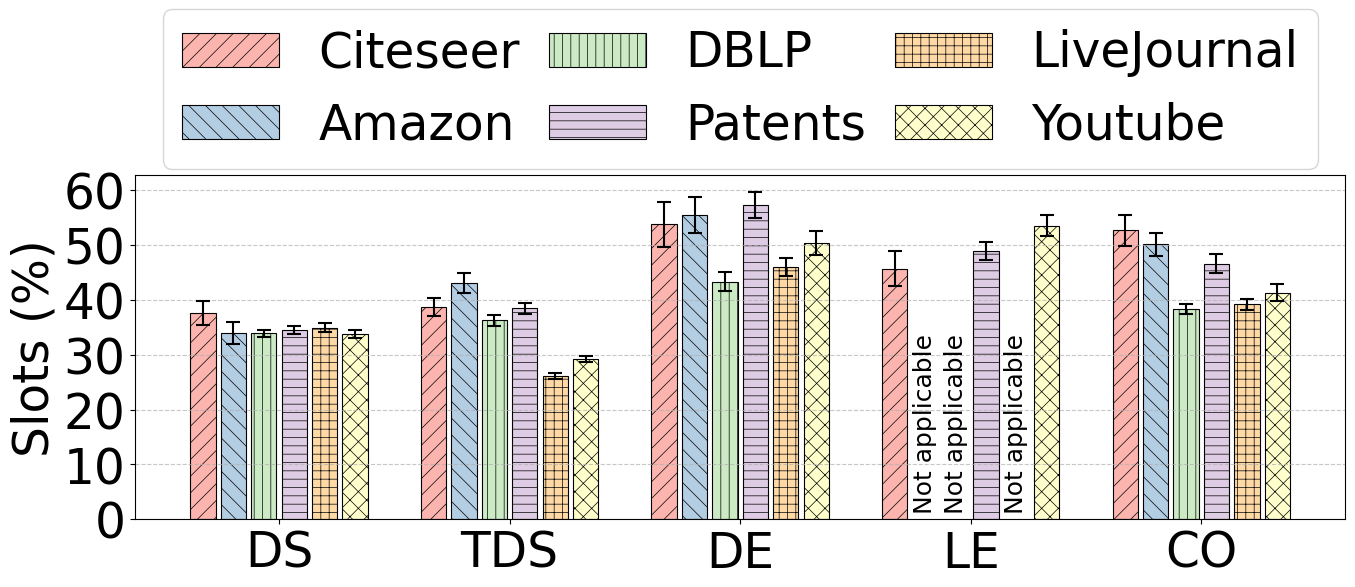

In [12]:
grouping_columns = ['obj_function']
plot_average_by_group_and_initial_solutions(df, grouping_columns, 'retiring', 'retiring_confidence_interval', 'Slots (%)', 'ILS TMA Analysis Retiring')

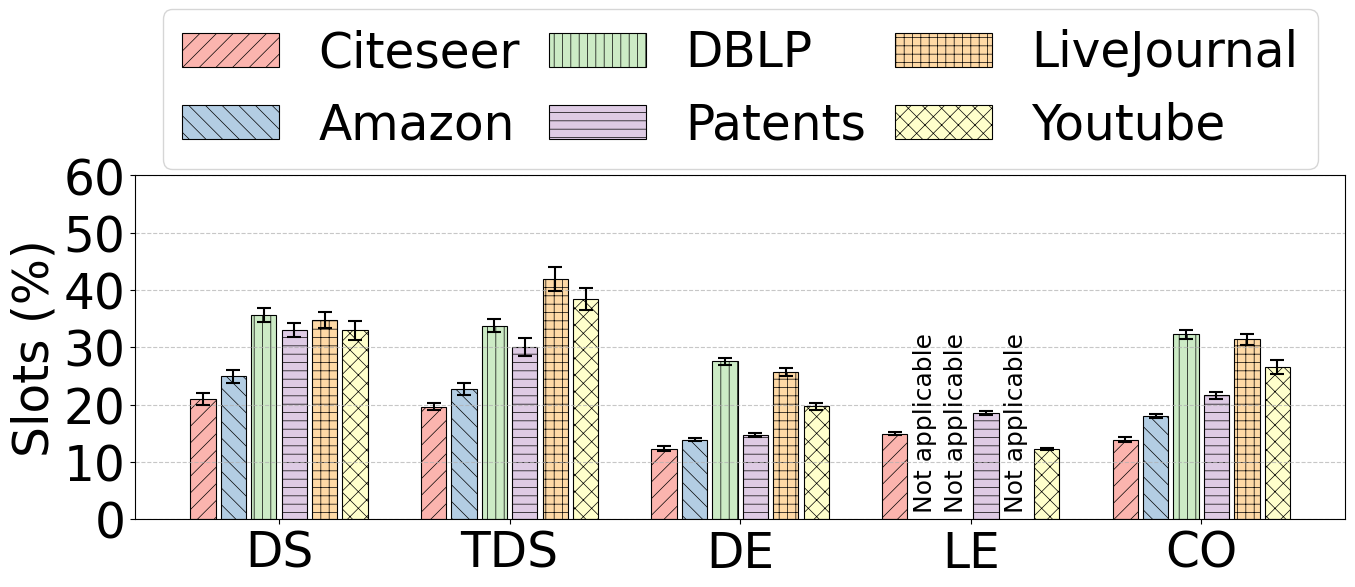

In [13]:
grouping_columns = ['obj_function']
plot_average_by_group_and_initial_solutions(df, grouping_columns, 'badspec', 'badspec_confidence_interval', 'Slots (%)', 'ILS TMA Analysis Bad Speculation')

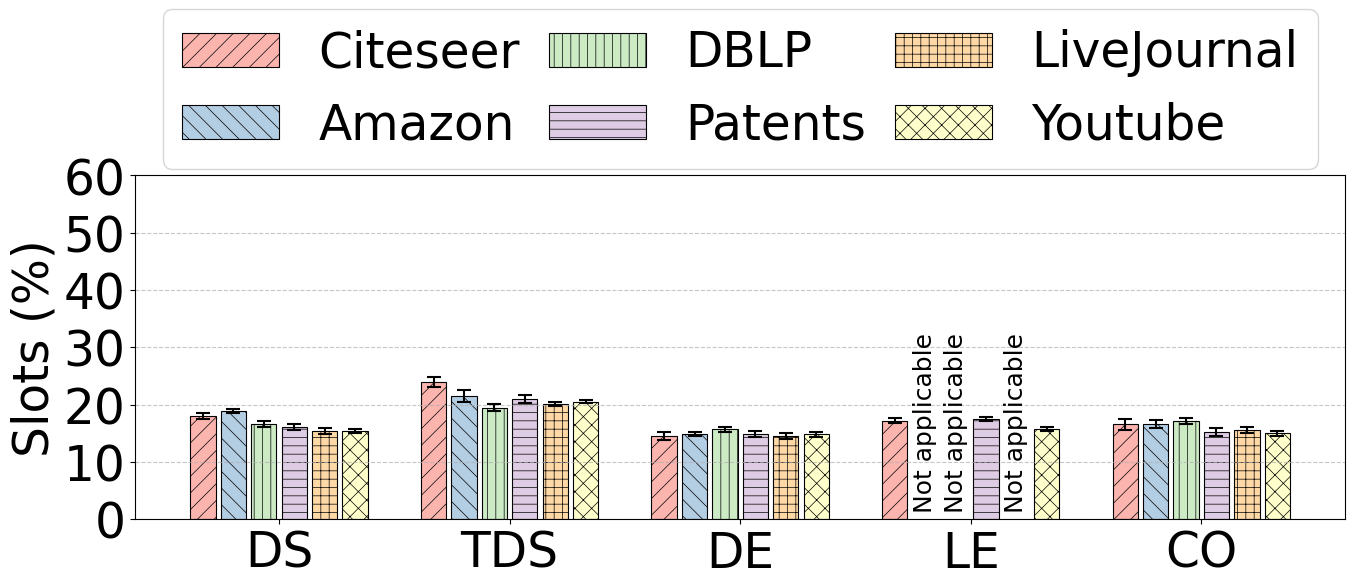

In [14]:
grouping_columns = ['obj_function']
plot_average_by_group_and_initial_solutions(df, grouping_columns, 'febound', 'febound_confidence_interval', 'Slots (%)', 'ILS TMA Analysis Frontend Bound')

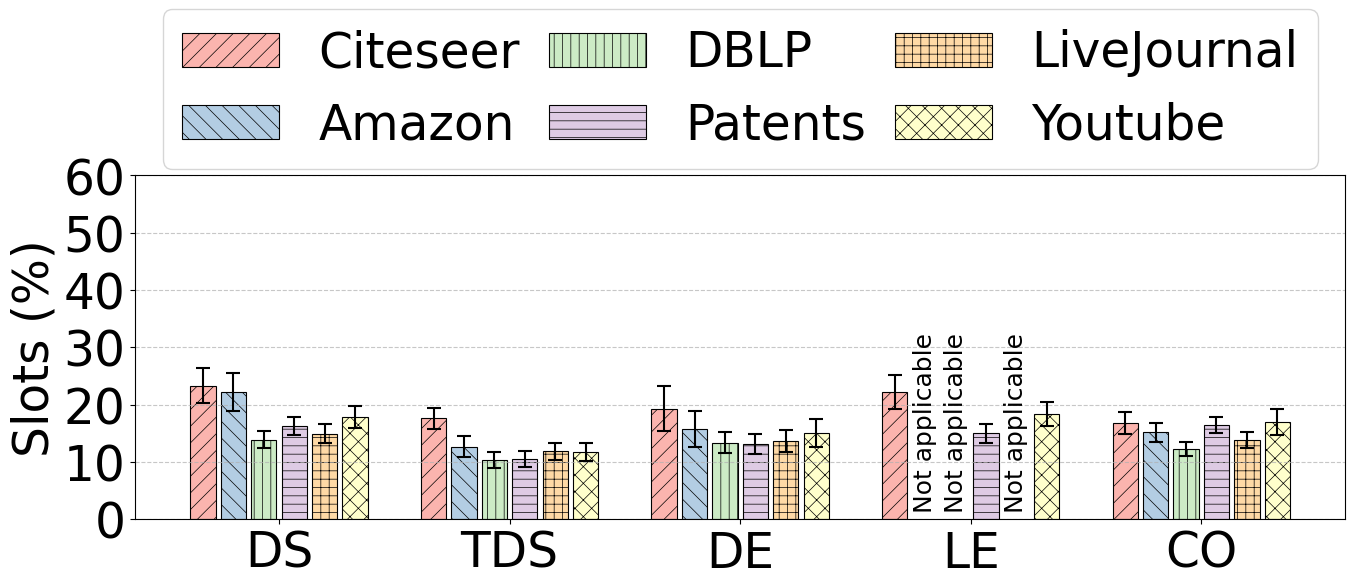

In [15]:
grouping_columns = ['obj_function']
plot_average_by_group_and_initial_solutions(df, grouping_columns, 'bebound', 'bebound_confidence_interval', 'Slots (%)', 'ILS TMA Analysis Backend Bound')

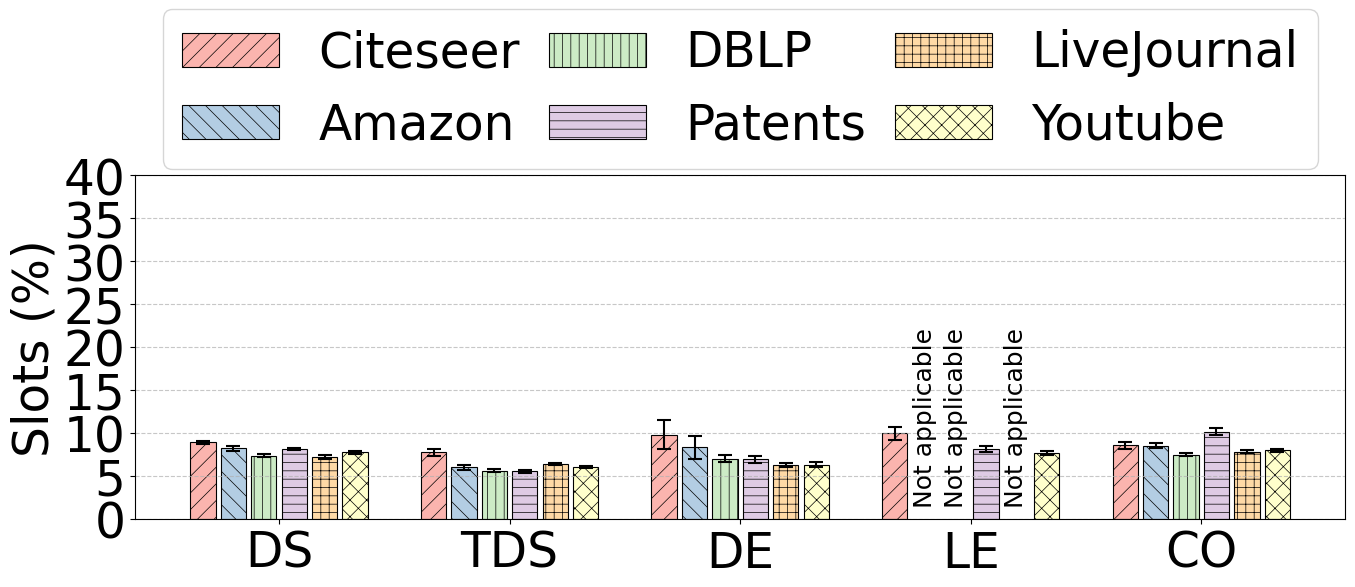

In [16]:
grouping_columns = ['obj_function']
plot_average_by_group_and_initial_solutions(df, grouping_columns, 'core_bound', 'core_bound_confidence_interval', 'Slots (%)', 'ILS TMA Analysis Backend Core Bound', yrange=range(0, 41, 5))

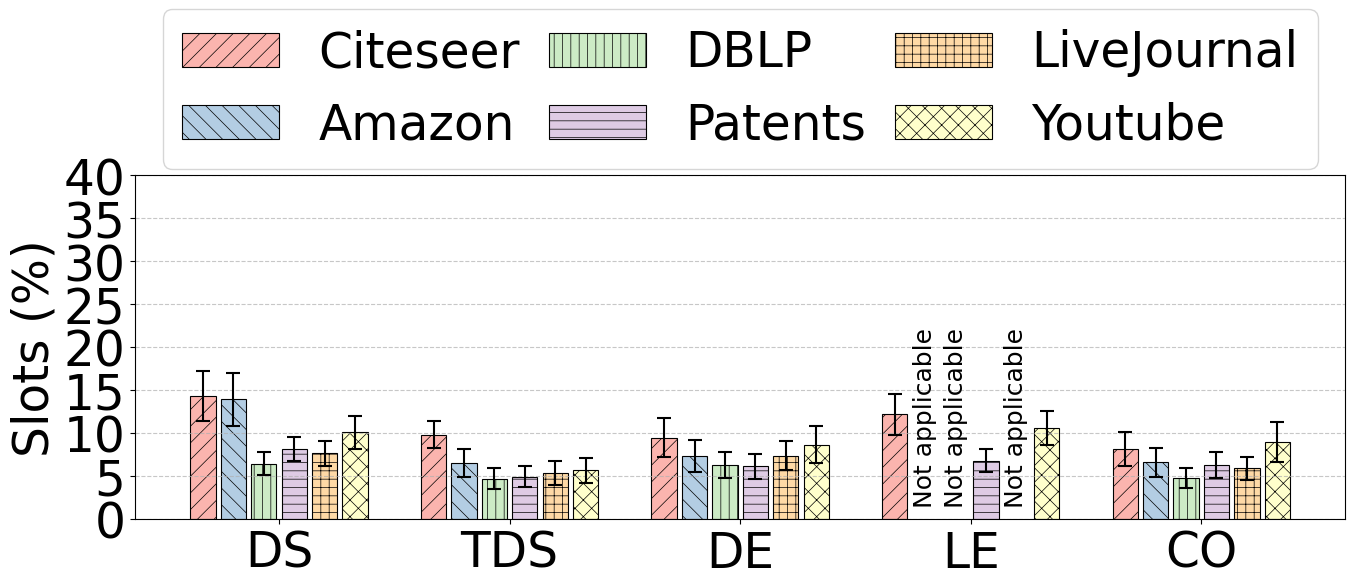

In [17]:
grouping_columns = ['obj_function']
plot_average_by_group_and_initial_solutions(df, grouping_columns, 'mem_bound', 'mem_bound_confidence_interval', 'Slots (%)', 'ILS TMA Analysis Backend Memory Bound', yrange=range(0, 41, 5))